# LAB3: Анализ сигналов ЭЭГ / EEG Signal Analysis
## Цель / Objective

Выполнить полный анализ сигналов ЭЭГ новорожденных с приступами:
- Загрузка EDF данных
- Локализация приступов
- Построение временных осциллограмм
- Усреднение по каналам
- Низкочастотная фильтрация
- Спектрограмма и вейвлет-скейлограмма

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import mne
import pywt
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

lab3_path = r'D:\Zhuomian\master\3th_2507-2607\IC\ES\lab3'
edf_file = os.path.join(lab3_path, 'eeg1.edf')

print("=" * 60)
print("3.1  Loading EDF Data")
print("=" * 60)

raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
sfreq = raw.info['sfreq']  # Частота дискретизации
n_channels = len(raw.ch_names)
n_times = raw.n_times
duration = n_times / sfreq

print(f"Частота дискретизации: {sfreq} Hz")
print(f"Количество каналов: {n_channels}")
print(f"Длительность: {duration:.2f} сек ({duration/60:.2f} мин)")
print(f"Каналы: {raw.ch_names}")

data, times = raw[:]

3.1 获取与解析EDF数据 / Loading EDF Data
Частота дискретизации: 256.0 Hz
Количество каналов: 21
Длительность: 6993.00 сек (116.55 мин)
Каналы: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']


---

In [ ]:
print("=" * 60)
print("3.2  Locating Seizure Periods")
print("=" * 60)

annotation_file = os.path.join(lab3_path, 'annotations_2017_A.csv')
annotation_df = pd.read_csv(annotation_file)
eeg1_annotations = annotation_df.iloc[:, 0].values

seizure_indices = np.where(eeg1_annotations == 1)[0]
window_duration = 4

print(f"Обнаружено {len(seizure_indices)} сегментов с приступами")

# Объединяем последовательные периоды
seizure_times_list = []
if len(seizure_indices) > 0:
    start = seizure_indices[0]
    for i in range(1, len(seizure_indices)):
        if seizure_indices[i] != seizure_indices[i-1] + 1:
            seizure_times_list.append((start * window_duration, (seizure_indices[i-1] + 1) * window_duration))
            start = seizure_indices[i]
    seizure_times_list.append((start * window_duration, (seizure_indices[-1] + 1) * window_duration))

print("Временные интервалы приступов:")
for i, (st, et) in enumerate(seizure_times_list[:5]):
    print(f"  Приступ {i+1}: {st:.0f} - {et:.0f} сек")

first_seizure_start, first_seizure_end = seizure_times_list[0]

3.2 定位癫痫发作时段 / Locating Seizure Periods
Обнаружено 1602 сегментов с приступами
Временные интервалы приступов:
  Приступ 1: 412 - 484 сек
  Приступ 2: 1264 - 1804 сек
  Приступ 3: 2964 - 3200 сек
  Приступ 4: 3812 - 3928 сек
  Приступ 5: 4712 - 4836 сек


---

## 3.3 Построение осциллограмм во время приступа / Plotting Seizure Waveform

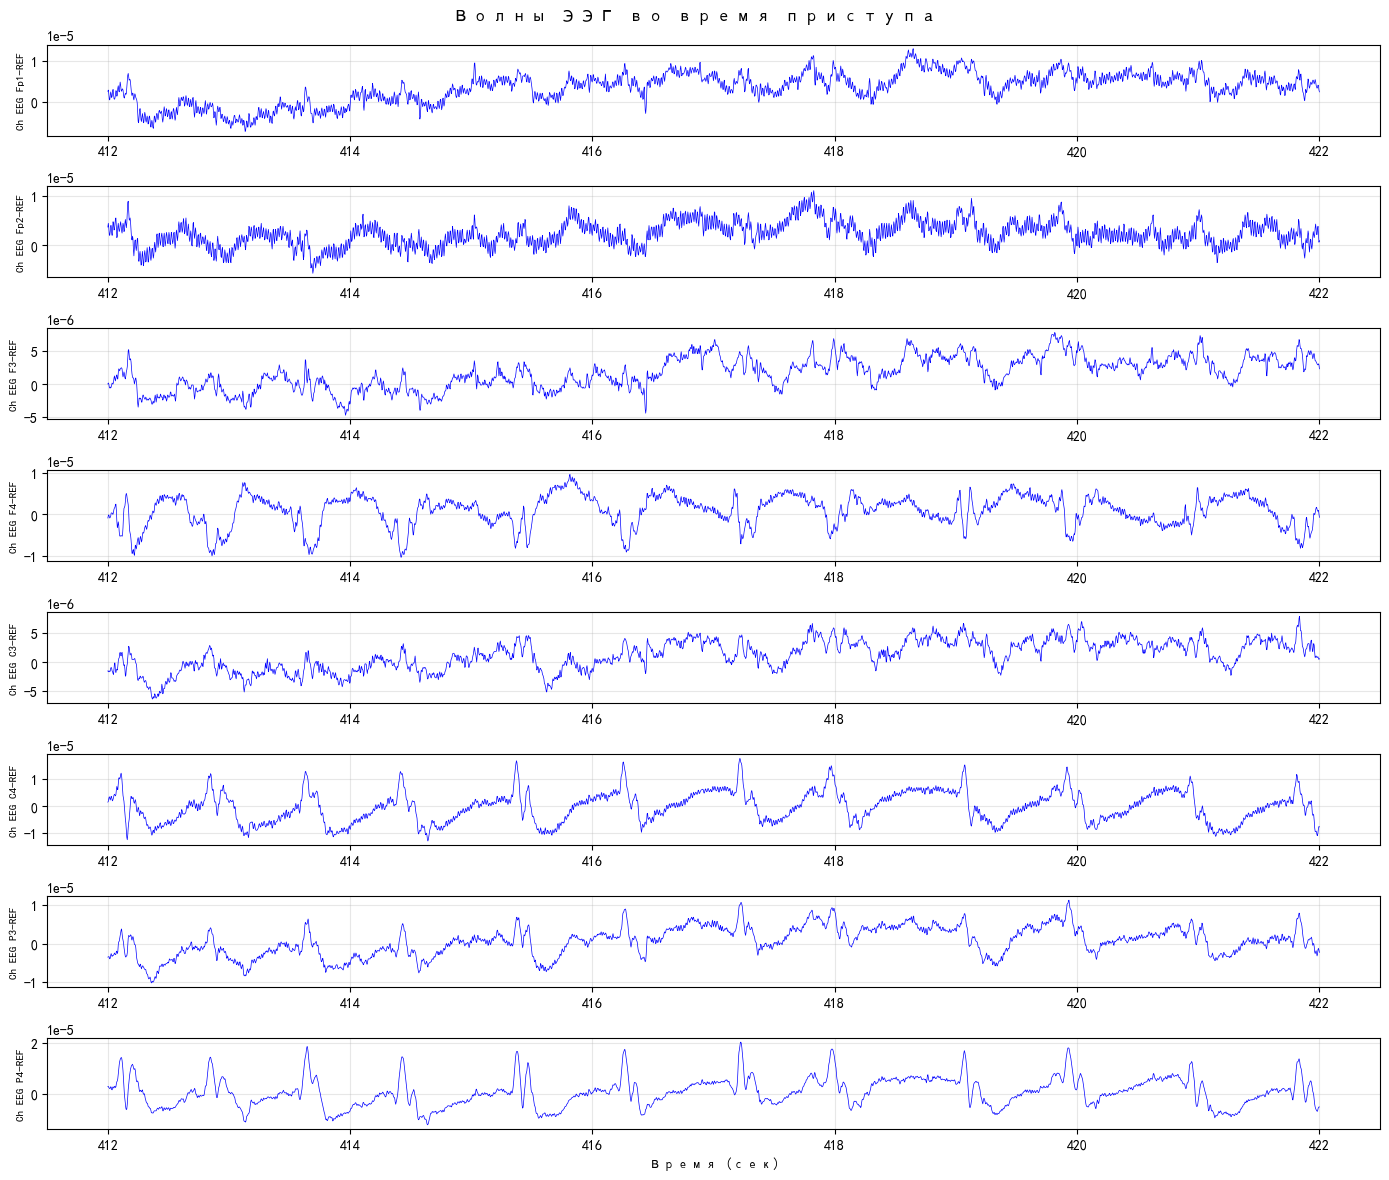

Сохранено: seizure_waveform.png


In [3]:
seizure_plot_start = first_seizure_start
seizure_plot_end = min(first_seizure_start + 10, first_seizure_end)

start_sample = int(seizure_plot_start * sfreq)
end_sample = int(seizure_plot_end * sfreq)
time_axis = np.linspace(seizure_plot_start, seizure_plot_end, end_sample - start_sample)

plot_channels = range(min(8, n_channels))

fig, axes = plt.subplots(len(plot_channels), 1, figsize=(14, 12))
fig.suptitle('Волны ЭЭГ во время приступа', fontsize=14, fontweight='bold')

for i, ch_idx in enumerate(plot_channels):
    ch_data = data[ch_idx, start_sample:end_sample]
    axes[i].plot(time_axis, ch_data, 'b-', linewidth=0.5)
    axes[i].set_ylabel(f'Ch {raw.ch_names[ch_idx]}', fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Время (сек)', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(lab3_path, 'seizure_waveform.png'), dpi=128, bbox_inches='tight')
plt.show()
print("Сохранено: seizure_waveform.png")

---

In [4]:
print("=" * 60)
print("3.4 Усреднение по каналам / Channel Averaging")
print("=" * 60)

avg_signal = np.mean(data, axis=0)
print(f"Усредненный сигнал: {avg_signal.shape}")
print(f"Количество каналов: {n_channels}")

3.4 Усреднение по каналам / Channel Averaging
Усредненный сигнал: (1790208,)
Количество каналов: 21


---

In [5]:
print("=" * 60)
print("3.5 Низкочастотная фильтрация 60Гц / Low-pass Filter 60Hz")
print("=" * 60)

filter_order = 4
cutoff_freq = 60
nyquist = sfreq / 2
normalized_cutoff = cutoff_freq / nyquist

b, a = signal.butter(filter_order, normalized_cutoff, btype='low')
filtered_signal = signal.filtfilt(b, a, avg_signal)

print(f"Фильтр: Butterworth порядок {filter_order}, частота среза {cutoff_freq} Гц")
print(f"Отфильтрованный сигнал: {filtered_signal.shape}")

3.5 Низкочастотная фильтрация 60Гц / Low-pass Filter 60Hz
Фильтр: Butterworth порядок 4, частота среза 60 Гц
Отфильтрованный сигнал: (1790208,)


---

3.6 Спектрограмма / Spectrogram


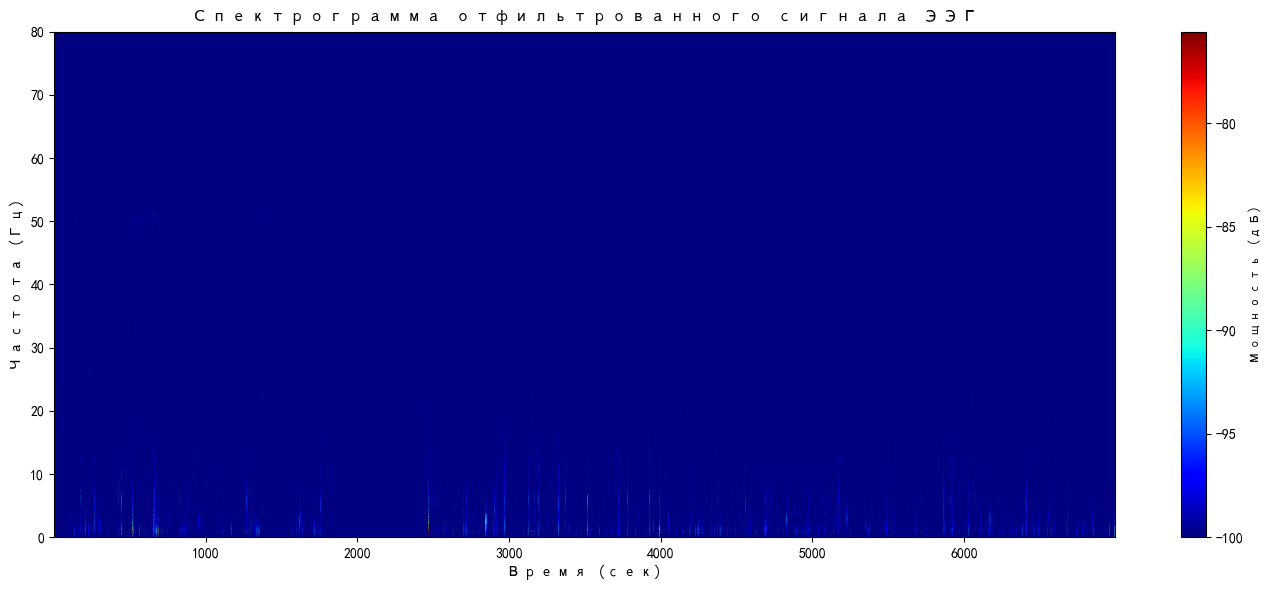

Сохранено: spectrogram.png


In [6]:
print("=" * 60)
print("3.6 Спектрограмма / Spectrogram")
print("=" * 60)

nperseg = min(256, n_times // 10)
noverlap = nperseg // 2

frequencies, times_stft, Sxx = signal.spectrogram(
    filtered_signal[:n_times], 
    fs=sfreq, 
    nperseg=nperseg,
    noverlap=noverlap,
    scaling='density'
)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(times_stft, frequencies, 10 * np.log10(Sxx + 1e-10), 
                  shading='gouraud', cmap='jet')
ax.set_ylabel('Частота (Гц)', fontsize=12)
ax.set_xlabel('Время (сек)', fontsize=12)
ax.set_title('Спектрограмма отфильтрованного сигнала ЭЭГ', fontsize=14, fontweight='bold')
ax.set_ylim([0, 80])

cbar = fig.colorbar(im, ax=ax, label='Мощность (дБ)')
plt.tight_layout()
plt.savefig(os.path.join(lab3_path, 'spectrogram.png'), dpi=128, bbox_inches='tight')
plt.show()
print("Сохранено: spectrogram.png")

---

3.7 Вейвлет-скейлограмма / Wavelet Scalogram


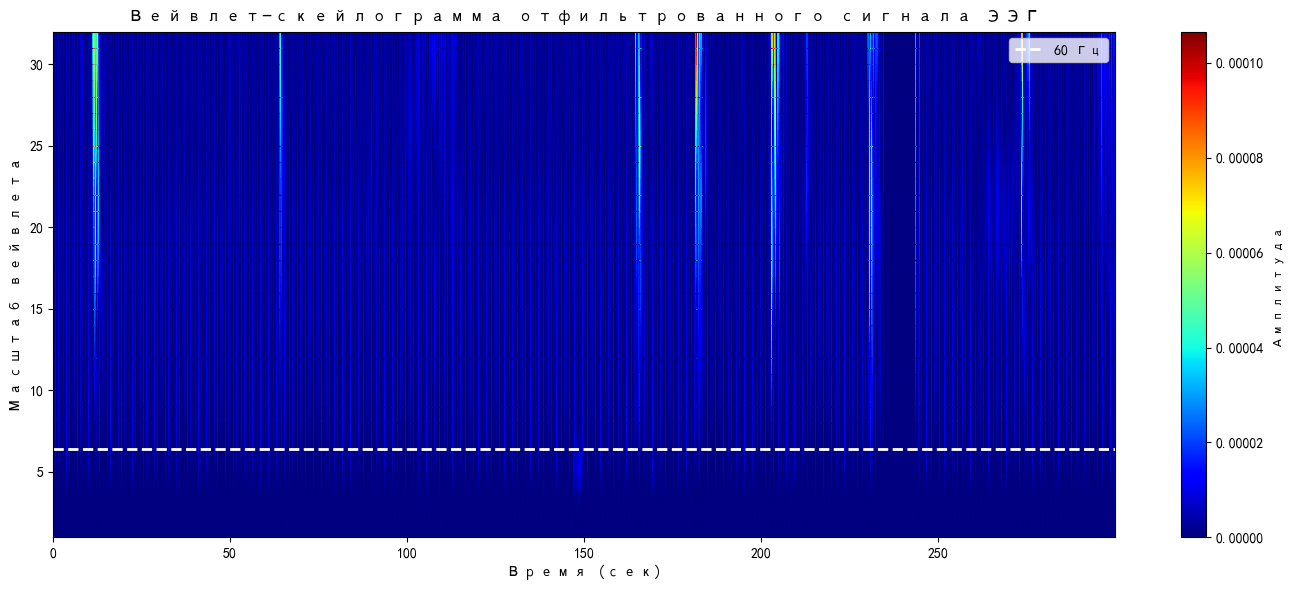

Сохранено: scalogram.png


In [7]:
print("=" * 60)
print("3.7 Вейвлет-скейлограмма / Wavelet Scalogram")
print("=" * 60)

scales = np.arange(1, 33)
mother_wavelet = 'cmor1.5-1.0'

n_samples = int(min(300, duration) * sfreq)
sig = filtered_signal[:n_samples]

coefficients, frequencies_cwt = pywt.cwt(sig, scales, mother_wavelet, sampling_period=1/sfreq)

time_axis_wvt = np.arange(n_samples) / sfreq

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(time_axis_wvt, scales, np.abs(coefficients), 
                  shading='gouraud', cmap='jet')
ax.set_ylabel('Масштаб вейвлета', fontsize=12)
ax.set_xlabel('Время (сек)', fontsize=12)
ax.set_title('Вейвлет-скейлограмма отфильтрованного сигнала ЭЭГ',
            fontsize=14, fontweight='bold')

fc = 1.5
ax.axhline(y=fc * sfreq / 60, color='white', linestyle='--', linewidth=2, label='60 Гц')
ax.legend(loc='upper right')

cbar = fig.colorbar(im, ax=ax, label='Амплитуда')
plt.tight_layout()
plt.savefig(os.path.join(lab3_path, 'scalogram.png'), dpi=128, bbox_inches='tight')
plt.show()
print("Сохранено: scalogram.png")

---

## Результаты / Results

1. **seizure_waveform.png**: Временные осциллогра EEG во время приступа
2. **spectrogram.png**: Спектрограмма отфильтрованного сигнала
3. **scalogram.png**: Вейвлет-скейлограмма

## Выводы / Conclusions

Работа выполнена успешно:
- Загружены EDF данные (21 канал, 256 Гц, ~7000 сек)
- Определены временные интервалы приступов
- Построены временные осциллогра для периода приступа
- Выполнено усреднение по всем каналам
- Проведена низкочастотная фильтрация (60 Гц)
- Построены спектрограмма и вейвлет-скейлограмма